In [18]:
import json

with open("data/games.json", "r") as f:
    games = json.load(f)
    
def build_matches_dict(games):
    matches = {}

    for g in games:
        mid = g["match_id"]

        # ustal orientację t1/t2 z pierwszej napotkanej gry w danym matchu
        if mid not in matches:
            matches[mid] = {
                "t1": g["t1_id"],      # albo g["t1_name"]
                "t2": g["t2_id"],      # albo g["t2_name"]
                "t1_score": 0,
                "t2_score": 0,
            }

        m = matches[mid]

        # wynik mapy z perspektywy tej gry
        game_t1_win = bool(g["t1_win"])

        # dopasuj perspektywę gry do perspektywy matchu (bo czasem t1/t2 może się zamienić)
        if g["t1_id"] == m["t1"] and g["t2_id"] == m["t2"]:
            # zgodna orientacja
            if game_t1_win:
                m["t1_score"] += 1
            else:
                m["t2_score"] += 1
        elif g["t1_id"] == m["t2"] and g["t2_id"] == m["t1"]:
            # odwrócona orientacja
            if game_t1_win:
                m["t2_score"] += 1
            else:
                m["t1_score"] += 1
        else:
            # dziwny przypadek: w ramach match_id pojawiła się inna para drużyn
            # można: pominąć, zalogować, albo rzucić wyjątek
            raise ValueError(
                f"Match {mid}: unexpected teams "
                f"({g['t1_id']},{g['t2_id']}) vs expected ({m['t1']},{m['t2']})"
            )

    return matches
matches = build_matches_dict(games)

In [19]:
def list_teams(games):
    teams = set()

    for game in games:
        teams.add(game.get("t1_name"))
        teams.add(game.get("t2_name"))

    return list(teams)


In [20]:
teams = list_teams(games)

In [21]:
print(len(matches))

38827


In [75]:
tournaments = set()
special_words = ["LCS", "LEC", "LCK", "LPL ", "LTA", "LFL", "LCP", "Worlds", "MSI", "Championship", "Mid-Season", "First Stand", "Invitational"]

for game in games:
    tournament = game["tournament"]
    if any(word.lower() in tournament.lower() for word in special_words):
        tournaments.add(tournament)
        
filtered_games = [g for g in games if g["tournament"] in tournaments]

In [ ]:
from collections import defaultdict, deque
from trueskill import Rating as TrueSkillRating
from openskill.models import PlackettLuce, BradleyTerryFull, ThurstoneMostellerFull
from glicko2 import Player  # pip install glicko2

MAX_GAME_HISTORY = 20
start_date = "2016-01-01"
X_date = "2024-01-01"
X_ctx = []     # tu będziesz miał featury kontekstowe pod ML

os_model = PlackettLuce()
tm_model = ThurstoneMostellerFull()
y_true = []
y_pred = {
    "team_elo": [],
    "team_ts": [],
    "team_os": [],
    "team_tm": [],
    "team_glicko": [],
    "team_wr5": [],
    "team_wr10": [],
    "team_streak": [],
    "player_elo": [],
    "player_ts": [],
    "player_os": [],
    "player_tm": [],
    "player_glicko": [],
}

team_rankings = {
    "ts": defaultdict(lambda: TrueSkillRating()),
    "os": defaultdict(lambda: os_model.rating()),
    # "bt": {},  # Bradley-Terry model removed
    "tm": defaultdict(lambda: tm_model.rating()),   # Thurstone-Mosteller model added
    "elo": defaultdict(lambda: 1500),
    "glicko": defaultdict(lambda: Player()),
    "wr_5": defaultdict(lambda: deque(maxlen=5)),
    "wr_10": defaultdict(lambda: deque(maxlen=10)),
    "streak": defaultdict(int),
}

player_rankings = {
    "ts": defaultdict(lambda: TrueSkillRating()),
    "os": defaultdict(lambda: os_model.rating()),
    "tm": defaultdict(lambda: tm_model.rating()),
    "elo": defaultdict(lambda: 1500.0),
    "glicko": defaultdict(lambda: Player()),
}

team_history = defaultdict(lambda: deque(maxlen=MAX_GAME_HISTORY))

In [81]:
ROLES = ["TOP", "JUNGLE", "MID", "ADC", "SUPPORT"]
def extract_team_game_stats(game):
    def _safe(v):
        return 0.0 if v is None else v

    def extract_for_side(side):
        team_key = f"{side}_stats"
        players_key = f"{side}_players"

        tstats = game.get(team_key, {}) or {}
        pstats_all = game.get(players_key, {}) or {}

        # team-level
        team_kills = _safe(tstats.get("kills"))
        team_towers = _safe(tstats.get("towers"))
        team_dragons = _safe(tstats.get("dragons"))
        team_nashors = _safe(tstats.get("nashors"))
        team_gold = _safe(tstats.get("gold"))
        game_duration = _safe(game.get("game_duration"))

        team_deaths = 0.0
        team_assists = 0.0
        team_gd15 = 0.0
        team_csd15 = 0.0
        team_xpd15 = 0.0
        team_vision_score = 0.0
        team_wards_placed = 0.0
        team_wards_destroyed = 0.0
        team_control_wards = 0.0

        features = {
            "team_kills": team_kills,
            "team_towers": team_towers,
            "team_dragons": team_dragons,
            "team_nashors": team_nashors,
            "team_gold": team_gold,
            "game_duration": game_duration,
        }

        # per-role + agregaty
        for role in ROLES:
            prole = pstats_all.get(role)
            if not prole:
                continue

            s = prole.get("stats", {}) or {}

            kills = _safe(s.get("kills"))
            deaths = _safe(s.get("deaths"))
            assists = _safe(s.get("assists"))
            kp = _safe(s.get("kp%"))
            gold_pct = _safe(s.get("gold%"))
            gpm = _safe(s.get("gpm"))
            cs = _safe(s.get("cs"))
            gd15 = _safe(s.get("gd@15"))
            csd15 = _safe(s.get("csd@15"))
            xpd15 = _safe(s.get("xpd@15"))
            dmg_pct = _safe(s.get("dmg%"))
            vision_score = _safe(s.get("vision_score"))
            wards_placed = _safe(s.get("wards_placed"))
            wards_destroyed = _safe(s.get("wards_destroyed"))
            control_wards = _safe(s.get("control_wards_purchased"))

            team_deaths += deaths
            team_assists += assists
            team_gd15 += gd15
            team_csd15 += csd15
            team_xpd15 += xpd15
            team_vision_score += vision_score
            team_wards_placed += wards_placed
            team_wards_destroyed += wards_destroyed
            team_control_wards += control_wards

            prefix = role.lower()  # top_, jungle_, mid_, adc_, support_

            features[f"{prefix}_kills"] = kills
            features[f"{prefix}_deaths"] = deaths
            features[f"{prefix}_assists"] = assists
            features[f"{prefix}_kp"] = kp
            features[f"{prefix}_gold_pct"] = gold_pct
            features[f"{prefix}_gpm"] = gpm
            features[f"{prefix}_cs"] = cs
            features[f"{prefix}_gd15"] = gd15
            features[f"{prefix}_csd15"] = csd15
            features[f"{prefix}_xpd15"] = xpd15
            features[f"{prefix}_dmg_pct"] = dmg_pct
            features[f"{prefix}_vision_score"] = vision_score
            # features[f"{prefix}_wards_placed"] = wards_placed
            # features[f"{prefix}_wards_destroyed"] = wards_destroyed
            # features[f"{prefix}_control_wards"] = control_wards

        features["team_deaths"] = team_deaths
        features["team_assists"] = team_assists
        features["team_kda"] = (team_kills + team_assists) / max(1.0, team_deaths)
        features["team_gd15"] = team_gd15
        features["team_csd15"] = team_csd15
        features["team_xpd15"] = team_xpd15
        features["team_vision_score"] = team_vision_score
        # features["team_wards_placed"] = team_wards_placed
        # features["team_wards_destroyed"] = team_wards_destroyed
        # features["team_control_wards"] = team_control_wards

        # prosty gpm drużyny
        features["team_gpm"] = team_gold / game_duration if game_duration > 0 else 0.0

        # wynik meczu z perspektywy drużyny
        features["team_win"] = 1 if (side == "t1" and game.get("t1_win")) or (side == "t2" and game.get("t2_win")) else 0

        return features

    t1_features = extract_for_side("t1")
    t2_features = extract_for_side("t2")

    return t1_features, t2_features

sorted_games = sorted(games, key=lambda x: x["date"])
extract_team_game_stats(sorted_games[-1])

({'team_kills': 11,
  'team_towers': 1,
  'team_dragons': 2,
  'team_nashors': 0,
  'team_gold': 61200.0,
  'game_duration': 2207,
  'top_kills': 1.0,
  'top_deaths': 7.0,
  'top_assists': 7.0,
  'top_kp': 0.727,
  'top_gold_pct': 0.18899999999999997,
  'top_gpm': 315.0,
  'top_cs': 227.0,
  'top_gd15': -1454.0,
  'top_csd15': -21.0,
  'top_xpd15': -841.0,
  'top_dmg_pct': 0.247,
  'top_vision_score': 40.0,
  'jungle_kills': 0.0,
  'jungle_deaths': 2.0,
  'jungle_assists': 8.0,
  'jungle_kp': 0.727,
  'jungle_gold_pct': 0.17800000000000002,
  'jungle_gpm': 297.0,
  'jungle_cs': 226.0,
  'jungle_gd15': -477.0,
  'jungle_csd15': 14.0,
  'jungle_xpd15': 518.0,
  'jungle_dmg_pct': 0.109,
  'jungle_vision_score': 81.0,
  'mid_kills': 8.0,
  'mid_deaths': 4.0,
  'mid_assists': 1.0,
  'mid_kp': 0.818,
  'mid_gold_pct': 0.295,
  'mid_gpm': 490.0,
  'mid_cs': 373.0,
  'mid_gd15': 212.0,
  'mid_csd15': 24.0,
  'mid_xpd15': -438.0,
  'mid_dmg_pct': 0.34299999999999997,
  'mid_vision_score': 27.0,

In [82]:
import math
from src.utils.rankings._elo import expected_win_elo
import trueskill as ts
from tqdm import tqdm
from src.utils.rankings._ts import expected_trueskill_win
from src.utils.rankings._os import expected_openskill_win
SCALE = 173.7178  

def _g(phi):
    return 1.0 / math.sqrt(1.0 + 3.0 * phi * phi / (math.pi ** 2))

def _team_summary(players):
    ratings = [p.getRating() for p in players]
    rds     = [p.getRd()      for p in players]
    team_rating = sum(ratings) / len(ratings)
    team_rd = math.sqrt(sum(rd ** 2 for rd in rds) / len(rds))
    return team_rating, team_rd

def expected_glicko_win(team1, team2):
    r1, rd1 = _team_summary(team1)
    r2, rd2 = _team_summary(team2)

    mu1  = (r1 - 1500.0) / SCALE
    mu2  = (r2 - 1500.0) / SCALE
    phi1 = rd1 / SCALE
    phi2 = rd2 / SCALE

    g2 = _g(phi2)
    return 1.0 / (1.0 + math.exp(-g2 * (mu1 - mu2)))


def ts_win_prob(r1: ts.Rating, r2: ts.Rating):
    delta_mu = r1.mu - r2.mu
    sum_sigma_sq = r1.sigma ** 2 + r2.sigma ** 2
    denom = math.sqrt(2 * (ts.BETA ** 2) + sum_sigma_sq)
    return 0.5 * (1.0 + math.erf(delta_mu / (denom * math.sqrt(2.0))))

def glicko_win_prob(p1: Player, p2: Player):
    q = math.log(10) / 400
    g = 1 / math.sqrt(1 + 3 * q*q * p2.rd*p2.rd / (math.pi**2))
    return 1 / (1 + 10 ** ( -g * (p1.rating - p2.rating) / 400 ))

def glicko_update(p1: Player, p2: Player, t1_win: bool):
    if t1_win:
        p1.update_player([p2.rating], [p2.rd], [1])
        p2.update_player([p1.rating], [p1.rd], [0])
    else:
        p1.update_player([p2.rating], [p2.rd], [0])
        p2.update_player([p1.rating], [p1.rd], [1])

def winrate_prob(hist1, hist2):
    wr1 = sum(hist1) / len(hist1) if hist1 else 0.5
    wr2 = sum(hist2) / len(hist2) if hist2 else 0.5
    denom = wr1 + wr2
    if denom == 0:
        return 0.5
    return wr1 / denom

def streak_prob(s1, s2, scale=3.0):
    return 1.0 / (1.0 + math.exp(-(s1 - s2) / scale))


def _agg_history(team):
    hist = team_history[team]
    if not hist:
        return {}
    acc = {}
    for gstats in hist:
        for k, v in gstats.items():
            if isinstance(v, (int, float)):
                acc.setdefault(k, []).append(v)
    return {k: sum(vs) / len(vs) for k, vs in acc.items()}


def update_gl_players(team1: list[Player], team2: list[Player], t1_win: bool):
    t1_snapshot = [(p.getRating(), p.getRd()) for p in team1]
    t2_snapshot = [(p.getRating(), p.getRd()) for p in team2]

    # Precompute opponent rating/RD lists for each team
    t1_ratings = [r for (r, rd) in t1_snapshot]
    t1_rds     = [rd for (r, rd) in t1_snapshot]

    t2_ratings = [r for (r, rd) in t2_snapshot]
    t2_rds     = [rd for (r, rd) in t2_snapshot]

    # Outcomes
    score_t1 = 1.0 if t1_win else 0.0
    score_t2 = 1.0 - score_t1

    # Update team1 players (each vs all of team2)
    outcomes_vs_t2 = [score_t1] * len(t2_ratings)
    for player in team1:
        player.update_player(t2_ratings, t2_rds, outcomes_vs_t2)

    # Update team2 players (each vs all of team1)
    outcomes_vs_t1 = [score_t2] * len(t1_ratings)
    for player in team2:
        player.update_player(t1_ratings, t1_rds, outcomes_vs_t1)

def update_elo_players(team1: list[str], team2: list[str], t1_win: bool, player_rankings: dict[str, dict]):
    team1_r = [player_rankings["elo"][pid] for pid in team1]
    team2_r = [player_rankings["elo"][pid] for pid in team2]
    
    score = 1.0 if t1_win else 0.0
    team1_ranking = sum(team1_r) / len(team1_r)
    team2_ranking = sum(team2_r) / len(team2_r)
    expected1 = 1 / (1 + 10 ** ((team2_ranking - team1_ranking) / 400))
    expected2 = 1 - expected1
    
    for pid in team1:
        player_rankings["elo"][pid] += 32 * (score - expected1)
        
    for pid in team2:
        player_rankings["elo"][pid] += 32 * ((1 - score) - expected2)
    
def build_ctx_features(t1, t2):
    t1_agg = _agg_history(t1)
    t2_agg = _agg_history(t2)

    feats = {}
    keys = set(t1_agg.keys()) | set(t2_agg.keys())
    for k in keys:
        v1 = t1_agg.get(k, 0.0)
        v2 = t2_agg.get(k, 0.0)
        # feats[f"{k}_diff"] = v1 - v2
        feats[f"{k}_t1"] = v1
        feats[f"{k}_t2"] = v2
    return feats

def get_current_team_ratings_and_probs(t1, t2, team_rankings: dict[str, dict]):
    # ELO
    r1_elo = team_rankings["elo"][t1]
    r2_elo = team_rankings["elo"][t2]
    p1_elo = expected_win_elo(r1_elo, r2_elo)
    
    # TrueSkill
    r1_ts = team_rankings["ts"][t1]
    r2_ts = team_rankings["ts"][t2]
    p1_ts = ts_win_prob(r1_ts, r2_ts)

    # OpenSkill (PlackettLuce)
    r1_os = team_rankings["os"][t1]
    r2_os = team_rankings["os"][t2]
    p_os = os_model.predict_win(teams=[[r1_os], [r2_os]])
    p1_os = p_os[0]

    # Bradley-Terry (BradleyTerryFull)
    # r1_bt = bt_rankings[t1]
    # r2_bt = bt_rankings[t2]
    # p_bt = bt_model.predict_win(teams=[[r1_bt], [r2_bt]])
    # p1_bt = p_bt[0]
    # y_pred["bt"].append(p1_bt)
    
    r1_tm = team_rankings["tm"][t1]
    r2_tm = team_rankings["tm"][t2]
    p_tm = tm_model.predict_win(teams=[[r1_tm], [r2_tm]])
    p1_tm = p_tm[0]

    # Glicko-2
    r1_gl = team_rankings["glicko"][t1]
    r2_gl = team_rankings["glicko"][t2]
    p1_gl = glicko_win_prob(r1_gl, r2_gl)

    # winrate last 5 / 10
    r1_wr5 = team_rankings["wr_5"][t1]
    r2_wr5 = team_rankings["wr_5"][t2]
    r1_wr10 = team_rankings["wr_10"][t1]
    r2_wr10 = team_rankings["wr_10"][t2]
    p_wr5 = winrate_prob(team_rankings["wr_5"][t1], team_rankings["wr_5"][t2])
    p_wr10 = winrate_prob(team_rankings["wr_10"][t1], team_rankings["wr_10"][t2])

    # streak score
    r1_streak = team_rankings["streak"][t1]
    r2_streak = team_rankings["streak"][t2]
    s_streak = streak_prob(team_rankings["streak"][t1], team_rankings["streak"][t2])
    
    return {
        "t1": {
            "elo": r1_elo,
            "ts": r1_ts,
            "os": r1_os,
            # "bt": r1_bt,
            "tm": r1_tm,
            "gl": r1_gl,
            "wr5": sum(r1_wr5)/len(r1_wr5) if r1_wr5 else 0.,
            "wr10": sum(r1_wr10)/len(r1_wr10) if r1_wr10 else 0.,
            "streak": r1_streak,
        },
        "t2": {
            "elo": r2_elo,
            "ts": r2_ts,
            "os": r2_os,
            # "bt": r2_bt,
            "tm": r2_tm,
            "gl": r2_gl,
            "wr5": sum(r2_wr5)/len(r2_wr5) if r2_wr5 else 0.,
            "wr10": sum(r2_wr10)/len(r2_wr10) if r2_wr10 else 0.,
            "streak": r2_streak,
        },
        "probs": {
            "elo": p1_elo,
            "ts": p1_ts,
            "os": p1_os,
            #bt": p1_bt,
            "tm": p1_tm,
            "gl": p1_gl,
            "wr5": p_wr5,
            "wr10": p_wr10,
            "streak": s_streak,
        }
    }
    


def get_current_player_ratings_and_probs(t1: list[str], t2: list[str], player_rankings):
    
    
    t1_players = [
        {
            "elo": player_rankings["elo"][pid],
            "ts": player_rankings["ts"][pid],
            "os": player_rankings["os"][pid],
            "tm": player_rankings["tm"][pid],
            "glicko": player_rankings["glicko"][pid],
        } for pid in t1
    ]
    t2_players = [
        {
            "elo": player_rankings["elo"][pid],
            "ts": player_rankings["ts"][pid],
            "os": player_rankings["os"][pid],
            "tm": player_rankings["tm"][pid],
            "glicko": player_rankings["glicko"][pid],
        } for pid in t2
    ]
    
    team_1_elo = sum([r["elo"] for r in t1_players]) / len(t1_players)
    team_2_elo = sum([r["elo"] for r in t2_players]) / len(t2_players) 
    
    elo_expected = expected_win_elo(team_1_elo, team_2_elo)
    
    ts_team_1 = [r["ts"] for r in t1_players]
    ts_team_2 = [r["ts"] for r in t2_players]
    
    ts_expected = expected_trueskill_win(ts_team_1, ts_team_2)
    
    os_expected, *rest = os_model.predict_win(
        teams=[[r["os"] for r in t1_players], [r["os"] for r in t2_players]]
    )
    
    tm_expected, *rest = tm_model.predict_win(
        teams=[[r["tm"] for r in t1_players], [r["tm"] for r in t2_players]]
    )
    
    glicko_expected = expected_glicko_win(
        [r["glicko"] for r in t1_players],
        [r["glicko"] for r in t2_players]
    )
        
    return {
        "t1": t1_players,
        "t2": t2_players,
        "probs": {
            "elo": elo_expected,
            "ts": ts_expected,
            "os": os_expected,
            "tm": tm_expected,
            "gl": glicko_expected,
        }
    }
    
def update_teams(probs: dict, t1: str, t2: str, t1_win: bool, team_rankings: dict[str, dict | deque]):

    # --- Elo (TEAM) ---
    K = 32.0
    s1 = 1.0 if t1_win else 0.0
    s2 = 1.0 - s1
    p1_elo = probs["probs"]["elo"]
    r1_elo_pre = team_rankings["elo"][t1]
    r2_elo_pre = team_rankings["elo"][t2]
    
    team_rankings["elo"][t1] = r1_elo_pre + K * (s1 - p1_elo)
    team_rankings["elo"][t2] = r2_elo_pre + K * (s2 - (1.0 - p1_elo))

    # --- TrueSkill (TEAM) ---
    r1_ts = team_rankings["ts"][t1]
    r2_ts = team_rankings["ts"][t2]

    if t1_win:
        team_rankings["ts"][t1], team_rankings["ts"][t2] = ts.rate_1vs1(r1_ts, r2_ts)
    else:
        team_rankings["ts"][t2], team_rankings["ts"][t1] = ts.rate_1vs1(r2_ts, r1_ts)
    # --- OpenSkill PlackettLuce (TEAM) ---
    r1_os = team_rankings["os"][t1]
    r2_os = team_rankings["os"][t2]

    if t1_win:
        [[r1_new_os], [r2_new_os]] = os_model.rate([[r1_os], [r2_os]])
    else:
        [[r2_new_os], [r1_new_os]] = os_model.rate([[r2_os], [r1_os]])

    team_rankings["os"][t1], team_rankings["os"][t2] = r1_new_os, r2_new_os

    # --- Thurstone-Mosteller (TEAM) ---
    r1_tm = team_rankings["tm"][t1]
    r2_tm = team_rankings["tm"][t2]

    if t1_win:
        [[r1_new_tm], [r2_new_tm]] = tm_model.rate([[r1_tm], [r2_tm]])
    else:
        [[r2_new_tm], [r1_new_tm]] = tm_model.rate([[r2_tm], [r1_tm]])

    team_rankings["tm"][t1], team_rankings["tm"][t2] = r1_new_tm, r2_new_tm

    # --- Glicko-2 (TEAM) ---
    r1_gl = team_rankings["glicko"][t1]
    r2_gl = team_rankings["glicko"][t2]
    glicko_update(r1_gl, r2_gl, t1_win)
    # glicko_update should mutate the Player objects in-place,
    # so glicko_rankings[t1], glicko_rankings[t2] are updated automatically.

    # --- Winrate history (TEAM) ---
    team_rankings["wr_5"][t1].append(s1)
    team_rankings["wr_5"][t2].append(s2)
    team_rankings["wr_10"][t1].append(s1)
    team_rankings["wr_10"][t2].append(s2)

    # --- Streak (TEAM) ---
    if t1_win:
        team_rankings["streak"][t1] = team_rankings["streak"][t1] + 1 if team_rankings["streak"][t1] > 0 else 1
        team_rankings["streak"][t2] = team_rankings["streak"][t2] - 1 if team_rankings["streak"][t2] < 0 else -1
    else:
        team_rankings["streak"][t2] = team_rankings["streak"][t2] + 1 if team_rankings["streak"][t2] > 0 else 1
        team_rankings["streak"][t1] = team_rankings["streak"][t1] - 1 if team_rankings["streak"][t1] < 0 else -1
        
def update_players(t1_players: list[str],
                   t2_players: list[str], 
                   t1_win: bool,
                   player_rankings: dict[str, dict]
                   ):

    # --- Elo (PLAYERS) ---
    update_elo_players(
        t1_players,
        t2_players,
        t1_win,
        player_rankings
    )

    # --- TrueSkill (PLAYERS, proper teams) ---
    t1_ts = [player_rankings["ts"][pid] for pid in t1_players]
    t2_ts = [player_rankings["ts"][pid] for pid in t2_players]

    if t1_win:
        new_t1_ts, new_t2_ts = ts.rate([t1_ts, t2_ts], ranks=[0, 1])
    else:
        new_t2_ts, new_t1_ts = ts.rate([t2_ts, t1_ts], ranks=[0, 1])

    for pid, r_new in zip(t1_players, new_t1_ts):
        player_rankings["ts"][pid] = r_new
    for pid, r_new in zip(t2_players, new_t2_ts):
        player_rankings["ts"][pid] = r_new

    # --- OpenSkill PlackettLuce (PLAYERS) ---
    t1_os = [player_rankings["os"][pid] for pid in t1_players]
    t2_os = [player_rankings["os"][pid] for pid in t2_players]
    if t1_win:
        new_t1_os, new_t2_os = os_model.rate([t1_os, t2_os], ranks=[0, 1])
    else:
        new_t2_os, new_t1_os = os_model.rate([t2_os, t1_os], ranks=[0, 1])

    for pid, r_new in zip(t1_players, new_t1_os):
        player_rankings["os"][pid] = r_new
    for pid, r_new in zip(t2_players, new_t2_os):
        player_rankings["os"][pid] = r_new

    # --- Thurstone-Mosteller (PLAYERS) ---
    t1_tm = [player_rankings["tm"][pid] for pid in t1_players]
    t2_tm = [player_rankings["tm"][pid] for pid in t2_players]  
    if t1_win:
        new_t1_tm, new_t2_tm = tm_model.rate([t1_tm, t2_tm], ranks=[0, 1])
    else:
        new_t2_tm, new_t1_tm = tm_model.rate([t2_tm, t1_tm], ranks=[0, 1])

    for pid, r_new in zip(t1_players, new_t1_tm):
        player_rankings["tm"][pid] = r_new
    for pid, r_new in zip(t2_players, new_t2_tm):
        player_rankings["tm"][pid] = r_new

    t1_gl = [player_rankings["glicko"][pid] for pid in t1_players]
    t2_gl = [player_rankings["glicko"][pid] for pid in t2_players]
    
    update_gl_players(
        t1_gl,
        t2_gl,
        t1_win
    )


In [83]:



X_date = "2022-01-01"
start_date = "2020-01-01"

filtered_games = sorted(games, key=lambda x: (x["date"], x["match_id"], x["game_id"]))
filtered_games = [g for g in filtered_games if g["date"] >= start_date]
print(len(filtered_games))


X_ranks = []

def flatten_team_probs(team_probs: dict[str, dict]) -> dict[str, float]:
    flat = {}
    for side in ["t1", "t2"]:
        for k, v in team_probs[side].items():
            if k in ["ts", "os", "tm"]:
                flat[f"{side}_{k}_mu"] = v.mu
                flat[f"{side}_{k}_sigma"] = v.sigma
                continue
            elif k == "gl":
                flat[f"{side}_{k}_rating"] = v.getRating()
                flat[f"{side}_{k}_rd"] = v.getRd()
                continue
            
            flat[f"{side}_{k}"] = v
            
    for k, v in team_probs["probs"].items():
        flat[f"prob_{k}"] = v

    return flat

def flatten_player_probs(player_probs: dict[str, list[dict]]) -> dict[str, float]:
    flat = {}
    for side in ["t1", "t2"]:
        for i, pinfo in enumerate(player_probs[side]):
            prefix = f"{side}_player{i+1}"
            for k, v in pinfo.items():
                if k in ["ts", "os", "tm"]:
                    flat[f"{prefix}_{k}_mu"] = v.mu
                    flat[f"{prefix}_{k}_sigma"] = v.sigma
                    continue
                elif k == "glicko":
                    flat[f"{prefix}_{k}_rating"] = v.getRating()
                    flat[f"{prefix}_{k}_rd"] = v.getRd()
                    continue
                
                flat[f"{prefix}_{k}"] = v
    for k, v in player_probs["probs"].items():
        flat[f"prob_player_{k}"] = v
    return flat

seen_matches = set()

for g in tqdm(filtered_games, desc="Processing games"):
    t1 = g["t1_name"]
    t2 = g["t2_name"]
    t1_id = g["t1_id"]
    t2_id = g["t2_id"]
    t1_win = bool(g["t1_win"])
    y = 1 if t1_win else 0
    game_date = g["date"]
    
    mid = g["match_id"]
    gid = g["game_id"]
    # featury kontekstowe na bazie HISTORYCZNYCH gier (przed tym meczem)
    ctx_feats = build_ctx_features(t1, t2)
    seen = mid in seen_matches
    team_1 = [g["t1_players"][role]["player_id"] for role in ROLES if role in g["t1_players"]]
    team_2 = [g["t2_players"][role]["player_id"] for role in ROLES if role in g["t2_players"]]
    
    tprobs = get_current_team_ratings_and_probs(t1_id, t2_id, team_rankings)
    pprobs = get_current_player_ratings_and_probs(team_1, team_2, player_rankings)
    
    save_pred = False
    if not seen and game_date >= X_date:
        y_pred["team_elo"].append(tprobs["probs"]["elo"])
        y_pred["team_ts"].append(tprobs["probs"]["ts"])
        y_pred["team_os"].append(tprobs["probs"]["os"])
        # "team_bt": [tprobs["probs"]["bt"]],
        y_pred["team_tm"].append(tprobs["probs"]["tm"])
        y_pred["team_glicko"].append(tprobs["probs"]["gl"])
        y_pred["team_wr5"].append(tprobs["probs"]["wr5"])
        y_pred["team_wr10"].append(tprobs["probs"]["wr10"])
        y_pred["team_streak"].append(tprobs["probs"]["streak"])
        y_pred["player_elo"].append(pprobs["probs"]["elo"])
        y_pred["player_ts"].append(pprobs["probs"]["ts"])
        y_pred["player_os"].append(pprobs["probs"]["os"])
        y_pred["player_tm"].append(pprobs["probs"]["tm"])
        y_pred["player_glicko"].append(pprobs["probs"]["gl"])
        if not mid in matches:
            print(f"Match ID {mid} not found in matches data.")
            continue
        
        match_info = matches[mid]
        match_t1 = match_info["t1"]
        match_t2 = match_info["t2"]
        t1_score = match_info["t1_score"]
        t2_score = match_info["t2_score"]
        # Swap team IDs if they don't match
        if (match_t1 != t1_id) or (match_t2 != t2_id):
            print(f"Match {mid}: team IDs do not match. Expected ({match_t1}, {match_t2}), got ({t1_id}, {t2_id}). Swapping.")
            t1_score, t2_score = t2_score, t1_score        
        
        match_winner = 1 if t1_score > t2_score else 0
        y_true.append(match_winner)
        X_ctx.append(ctx_feats)
        X_ranks.append({**flatten_team_probs(tprobs), **flatten_player_probs(pprobs)})
        seen_matches.add(mid)
        save_pred = True
        
    # update rankingów
    update_teams(tprobs, t1_id, t2_id, t1_win, team_rankings)
    update_players(team_1, team_2, t1_win, player_rankings)

    # zapis statystyk z TEGO meczu do historii (po użyciu ich jako label)
    t1_stats, t2_stats = extract_team_game_stats(g)
    team_history[t1].append(t1_stats)
    team_history[t2].append(t2_stats)


44968


Processing games: 100%|██████████| 44968/44968 [01:41<00:00, 442.66it/s]


Elo: 19132 predictions
TrueSkill: 19132 predictions
OpenSkill: 19132 predictions
Thurstone-Mosteller: 19132 predictions
Glicko-2: 19132 predictions
Winrate-5: 19132 predictions
Streak: 19132 predictions
Player-Elo: 19132 predictions
Player-TrueSkill: 19132 predictions
Player-OpenSkill: 19132 predictions
Player-Thurstone-Mosteller: 19132 predictions
Player-Glicko-2: 19132 predictions


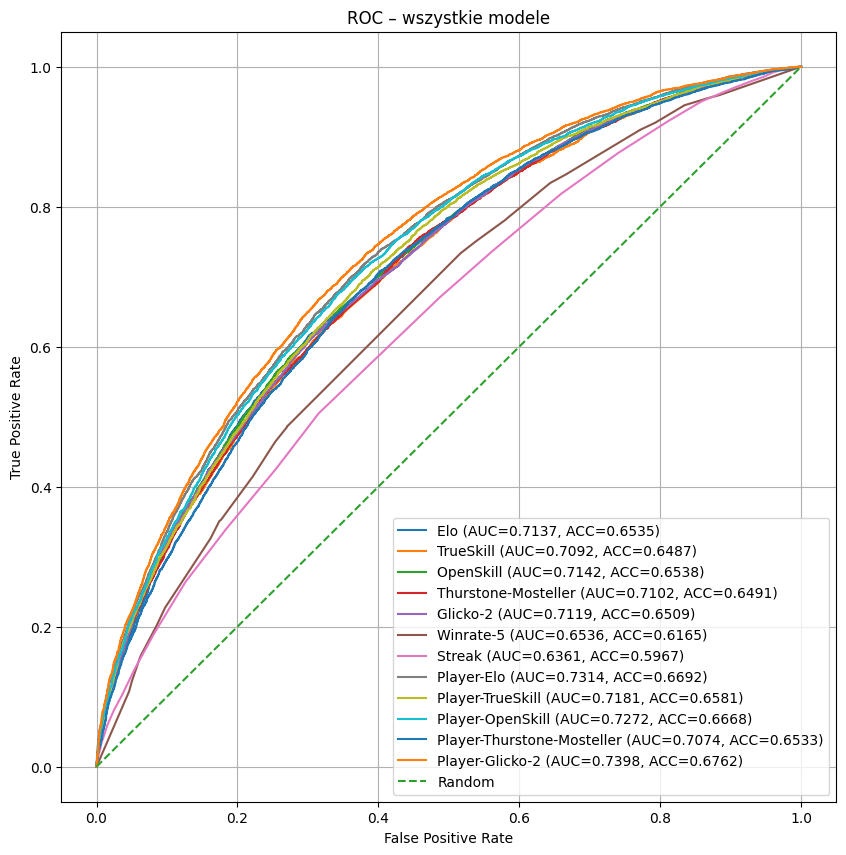

Elo: AUC=0.7137, ACC=0.6535
TrueSkill: AUC=0.7092, ACC=0.6487
OpenSkill: AUC=0.7142, ACC=0.6538
Thurstone-Mosteller: AUC=0.7102, ACC=0.6491
Glicko-2: AUC=0.7119, ACC=0.6509
Winrate-5: AUC=0.6536, ACC=0.6165
Streak: AUC=0.6361, ACC=0.5967
Player-Elo: AUC=0.7314, ACC=0.6692
Player-TrueSkill: AUC=0.7181, ACC=0.6581
Player-OpenSkill: AUC=0.7272, ACC=0.6668
Player-Thurstone-Mosteller: AUC=0.7074, ACC=0.6533
Player-Glicko-2: AUC=0.7398, ACC=0.6762


In [84]:


from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# zakładam, że masz już:
# y_true, elo_pred, ts_pred, os_pred, bt_pred

results = {}
preds = {
    "Elo": y_pred["team_elo"],
    "TrueSkill": y_pred["team_ts"],
    "OpenSkill": y_pred["team_os"],
    "Thurstone-Mosteller": y_pred["team_tm"],
    "Glicko-2": y_pred["team_glicko"],
    "Winrate-5": y_pred["team_wr5"],
    "Streak": y_pred["team_streak"],
    "Player-Elo": y_pred["player_elo"],
    "Player-TrueSkill": y_pred["player_ts"],
    "Player-OpenSkill": y_pred["player_os"],
    "Player-Thurstone-Mosteller": y_pred["player_tm"],
    "Player-Glicko-2": y_pred["player_glicko"],
}

for name, scores in preds.items():
    print(f"{name}: {len(scores)} predictions")

plt.figure(figsize=(10, 10))

for name, scores in preds.items():
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)
    acc = accuracy_score(y_true, [1 if p >= 0.5 else 0 for p in scores])

    results[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc,
        "acc": acc,
    }

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f}, ACC={acc:.4f})")

# linia losowa
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – wszystkie modele")
plt.legend()
plt.grid(True)
plt.show()

# wypisanie metryk liczbowych
for name, r in results.items():
    print(f"{name}: AUC={r['auc']:.4f}, ACC={r['acc']:.4f}")


        t1_elo   t1_ts_mu  t1_ts_sigma   t1_os_mu  t1_os_sigma   t1_tm_mu  \
0  1493.359775  25.372536     3.678953  24.338073     6.675270  23.697321   
1  1565.405090  35.946166     2.555196  34.929768     5.838363  35.945305   
2  1500.000000  25.000000     8.333333  25.000000     8.333333  25.000000   
3  1500.000000  25.000000     8.333333  25.000000     8.333333  25.000000   
4  1500.000000  25.000000     8.333333  25.000000     8.333333  25.000000   

   t1_tm_sigma  t1_gl_rating    t1_gl_rd  t1_wr5  ...  t2_player5_os_sigma  \
0     5.010387   1571.246075  147.032796     0.2  ...             5.233977   
1     3.847480   1933.148433  117.629319     0.4  ...             2.892284   
2     8.333333   1500.000000  350.000000     0.0  ...             8.333333   
3     8.333333   1500.000000  350.000000     0.0  ...             5.866413   
4     8.333333   1500.000000  350.000000     0.0  ...             6.099796   

   t2_player5_tm_mu  t2_player5_tm_sigma  t2_player5_glicko_rating  

d:\Melzak\dev\embedded-rift\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


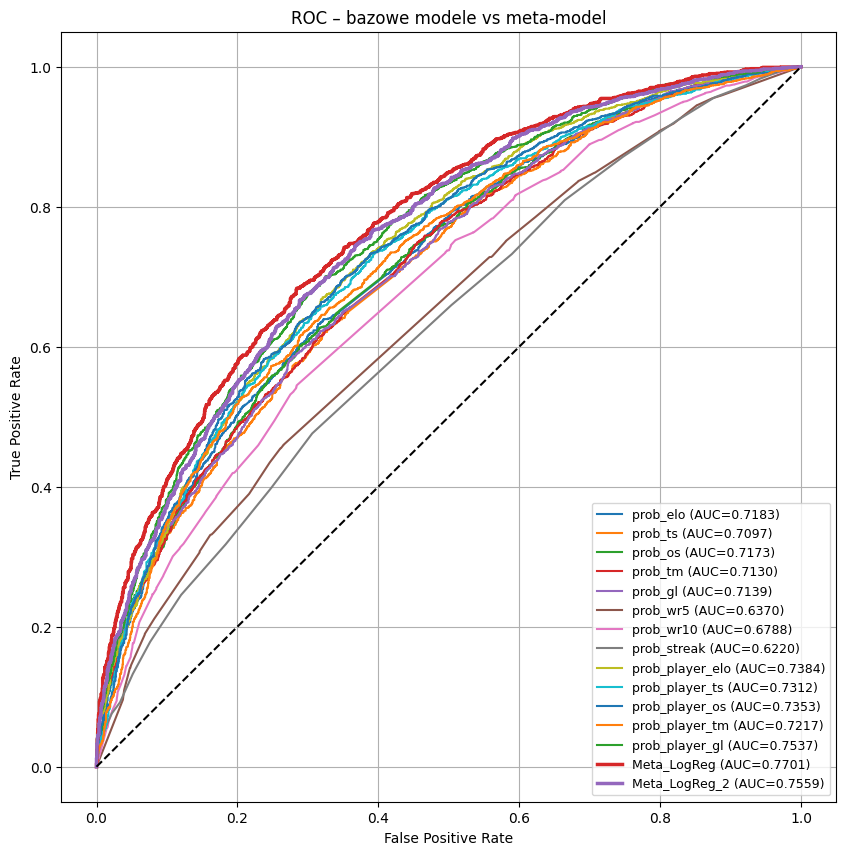


===== WYNIKI BAZOWYCH MODELI =====
prob_elo              AUC=0.7183  ACC=0.6519
prob_ts               AUC=0.7097  ACC=0.6462
prob_os               AUC=0.7173  ACC=0.6527
prob_tm               AUC=0.7130  ACC=0.6483
prob_gl               AUC=0.7139  ACC=0.6472
prob_wr5              AUC=0.6370  ACC=0.6005
prob_wr10             AUC=0.6788  ACC=0.6318
prob_streak           AUC=0.6220  ACC=0.5866
prob_player_elo       AUC=0.7384  ACC=0.6755
prob_player_ts        AUC=0.7312  ACC=0.6705
prob_player_os        AUC=0.7353  ACC=0.6742
prob_player_tm        AUC=0.7217  ACC=0.6590
prob_player_gl        AUC=0.7537  ACC=0.6836

===== WYNIKI META-MODELI =====

=== Meta_LogReg ===
AUC:        0.7701
Accuracy:   0.6964
log_loss:   0.5660
Brier:      0.1930
F1:         0.7348
Precision:  0.7114
Recall:     0.7598

=== Meta_LogReg_2 ===
AUC:        0.7559
Accuracy:   0.6880
log_loss:   0.5845
Brier:      0.2002
F1:         0.7139
Precision:  0.7251
Recall:     0.7032


In [90]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, f1_score, log_loss, precision_score, recall_score, roc_curve, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb

# ---------------------- DATAFRAME ZE WSZYSTKIMI CECHAMI ----------------------

df_ranks = pd.DataFrame(X_ranks)
y = np.array(y_true)

print(df_ranks.head())
# wszystkie probabilistyczne cechy bazowych modeli
prob_cols = [c for c in df_ranks.columns ]
print("prob_cols:", prob_cols)

X = df_ranks[prob_cols].values
X_probs = df_ranks[[c for c in prob_cols if c.startswith("prob_")]].values

# ---------------------- PODZIAŁ DANYCH ----------------------

# UWAGA: jeśli chcesz czasowy → ustaw shuffle=False
X_train, X_test, y_train, y_test, X_probs_train, X_probs_test = train_test_split(
    X, y, X_probs,
    test_size=0.2,
    shuffle=False,
)


# ---------------------- ROC DLA BAZOWYCH MODELI ----------------------

base_results = {}

plt.figure(figsize=(10, 10))

for c in prob_cols:
    if not c.startswith("prob_"):
        continue
    proba = df_ranks[c].values
    # podział jak w meta-modelach
    proba_train, proba_test = train_test_split(
        proba,
        test_size=0.2,
        shuffle=False,
    )

    auc = roc_auc_score(y_test, proba_test)
    acc = accuracy_score(y_test, (proba_test >= 0.5).astype(int))

    base_results[c] = {"auc": auc, "acc": acc}

    fpr, tpr, _ = roc_curve(y_test, proba_test)
    plt.plot(fpr, tpr, label=f"{c} (AUC={auc:.4f})")

# ---------------------- META-MODELE ----------------------

models = {}

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
proba_logreg = logreg.predict_proba(X_test)[:, 1]
models["Meta_LogReg"] = proba_logreg

logres2 = LogisticRegression(max_iter=1000, class_weight="balanced")
logres2.fit(X_probs_train, y_train)
proba_logreg2 = logres2.predict_proba(X_probs_test)[:, 1]
models["Meta_LogReg_2"] = proba_logreg2

# # XGB
# xgb_model = xgb.XGBClassifier(
#     use_label_encoder=False,
#     eval_metric='logloss',
#     n_estimators=300,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
# )
# xgb_model.fit(X_train, y_train)
# proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
# models["Meta_XGB"] = proba_xgb

# # LGB
# lgb_model = lgb.LGBMClassifier(
#     objective="binary",
#     n_estimators=300,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
# )
# lgb_model.fit(X_train, y_train)
# proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
# models["Meta_LGB"] = proba_lgb

# ---------------------- ROC DLA META ----------------------

meta_results = {}

for name, proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, (proba >= 0.5).astype(int))
    ll = log_loss(y_test, proba)
    bsl = brier_score_loss(y_test, proba)
    f1 = f1_score(y_test, (proba >= 0.5).astype(int))
    precision = precision_score(y_test, (proba >= 0.5).astype(int))
    recall = recall_score(y_test, (proba >= 0.5).astype(int))
    meta_results[name] = {
        "auc": auc, "acc": acc,
        "log_loss": ll,
        "brier": bsl,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})", linewidth=2.5)

# ---------------------- RANDOM LINIA ----------------------

plt.plot([0, 1], [0, 1], linestyle="--", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – bazowe modele vs meta-model")
plt.grid(True)
plt.legend(fontsize=9)
plt.show()

# ---------------------- WYNIKI ----------------------

print("\n===== WYNIKI BAZOWYCH MODELI =====")
for name, r in base_results.items():
    print(f"{name:20s}  AUC={r['auc']:.4f}  ACC={r['acc']:.4f}")

print("\n===== WYNIKI META-MODELI =====")
for name, r in meta_results.items():
    print(f"\n=== {name} ===")
    print(f"AUC:        {r['auc']:.4f}")
    print(f"Accuracy:   {r['acc']:.4f}")
    print(f"log_loss:   {r['log_loss']:.4f}")
    print(f"Brier:      {r['brier']:.4f}")
    print(f"F1:         {r['f1']:.4f}")
    print(f"Precision:  {r['precision']:.4f}")
    print(f"Recall:     {r['recall']:.4f}")

Rozmiary danych: df_ranks=(19132, 127), df_ctx=(19132, 150), y=(19132,)
[LightGBM] [Info] Number of positive: 8060, number of negative: 7245
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2741
[LightGBM] [Info] Number of data points in the train set: 15305, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526625 -> initscore=0.106602
[LightGBM] [Info] Start training from score 0.106602


d:\Melzak\dev\embedded-rift\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Melzak\dev\embedded-rift\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Melzak\dev\embedded-rift\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:57:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Meta-only (prob_*, LogReg) ===
AUC:        0.7413
Accuracy:   0.6776
log_loss:   0.5930
Brier:      0.20391686216932719544203678196936380118131638
F1:         0.7136
Precision:  0.7021
Recall:     0.7253

=== Meta+CTX (meta_prob + X_ctx, LGBM) ===
AUC:        0.7251
Accuracy:   0.6506
log_loss:   0.7917
Brier:      0.24086516859800624623666465140559012070298195
F1:         0.6790
Precision:  0.6911
Recall:     0.6673


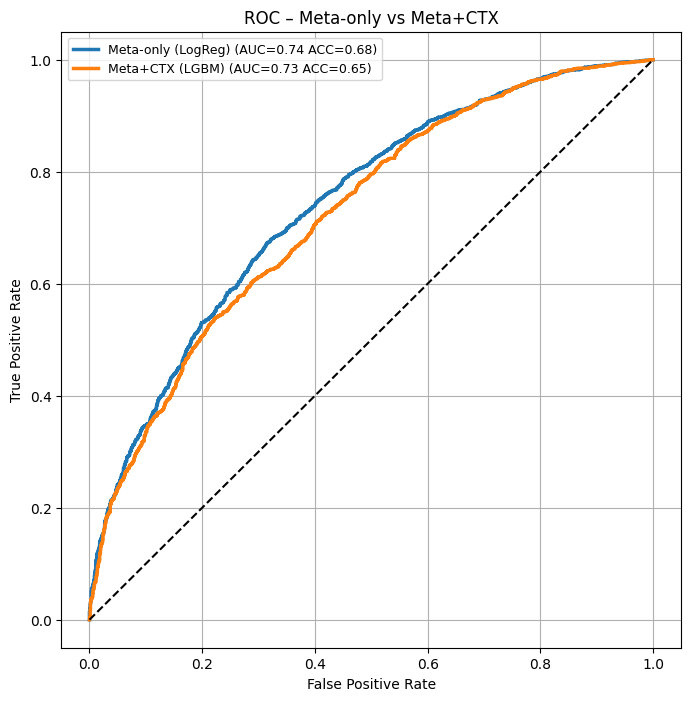

In [91]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    log_loss,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
import lightgbm as lgb

# ==========================
# 1. Dane wejściowe
# ==========================

df_ranks = pd.DataFrame(X_ranks)   # prob_* + rankingi
df_ctx   = pd.DataFrame(X_ctx)     # statystyki 40 gier
y        = np.array(y_true)

assert len(df_ranks) == len(df_ctx) == len(y), "Długości X_ranks, X_ctx i y_true muszą się zgadzać"
print(f"Rozmiary danych: df_ranks={df_ranks.shape}, df_ctx={df_ctx.shape}, y={y.shape}")
# ==========================
# 2. Podział czasowy train/test
# ==========================

n = len(y)
split_idx = int(n * 0.8)   # 80% najstarszych gier na train, 20% najnowszych na test

# --- warstwa 1: metamodel na prob_* ---

prob_cols = [c for c in df_ranks.columns if c.startswith("prob_")]
X_prob = df_ranks[prob_cols].values


X_prob_train, X_prob_test, y_train, y_test = train_test_split(
    X_prob,y,
    test_size=0.2,
    shuffle=False,
)

# ==========================
# 3. Metamodel (prob_* -> meta_prob)
# ==========================

meta_clf = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)
meta_clf.fit(X_prob_train, y_train)

meta_train = meta_clf.predict_proba(X_prob_train)[:, 1]
meta_test  = meta_clf.predict_proba(X_prob_test)[:, 1]

# ==========================
# 4. Warstwa 2: Meta + CTX
# ==========================

X_ctx_mat = df_ctx.values
X_ctx_train, X_ctx_test = train_test_split(
    X_ctx_mat,
    test_size=0.2,
    shuffle=False,
)

# finalne featury: [meta_prob, wszystkie ctx]
X_final_train = np.column_stack([meta_train, X_ctx_train])
X_final_test  = np.column_stack([meta_test,  X_ctx_test])

lgb_clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)
lgb_clf.fit(X_final_train, y_train)

proba_meta_ctx = lgb_clf.predict_proba(X_final_test)[:, 1]

# ==========================
# 5. Funkcja do oceny modeli
# ==========================

def eval_model(name, y_true, proba):
    pred = (proba >= 0.5).astype(int)
    print(f"\n=== {name} ===")
    print(f"AUC:        {roc_auc_score(y_true, proba):.4f}")
    print(f"Accuracy:   {accuracy_score(y_true, pred):.4f}")
    print(f"log_loss:   {log_loss(y_true, proba):.4f}")
    print(f"Brier:      {brier_score_loss(y_true, proba):.44f}")
    print(f"F1:         {f1_score(y_true, pred):.4f}")
    print(f"Precision:  {precision_score(y_true, pred):.4f}")
    print(f"Recall:     {recall_score(y_true, pred):.4f}")

# ==========================
# 6. Porównanie: meta-only vs meta+ctx
# ==========================

eval_model("Meta-only (prob_*, LogReg)", y_test, meta_test)
eval_model("Meta+CTX (meta_prob + X_ctx, LGBM)", y_test, proba_meta_ctx)

# PLOT ROC 
plt.figure(figsize=(8, 8))
fpr_meta, tpr_meta, _ = roc_curve(y_test, meta_test)
fpr_meta_ctx, tpr_meta_ctx, _ = roc_curve(y_test, proba_meta_ctx)   
plt.plot(fpr_meta, tpr_meta, label=f"Meta-only (LogReg) (AUC={roc_auc_score(y_test, meta_test):.2f} ACC={accuracy_score(y_test, (meta_test >= 0.5).astype(int)):.2f})", linewidth=2.5)
plt.plot(fpr_meta_ctx, tpr_meta_ctx, label=f"Meta+CTX (LGBM) (AUC={roc_auc_score(y_test, proba_meta_ctx):.2f} ACC={accuracy_score(y_test, (proba_meta_ctx >= 0.5).astype(int)):.2f})", linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – Meta-only vs Meta+CTX")
plt.grid(True)
plt.legend(fontsize=9)
plt.show()


In [ ]:
len(tournaments)        

385

In [48]:
with open("tournaments.txt", "w") as f:
    for tournament in sorted(tournaments):
        f.write(tournament + "\n")

In [40]:
with open("data/games.json", "r") as f:
    games = json.load(f)
    
max_date = max(g["date"] for g in games)

Calibration data (Meta-only):
Predicted: 0.0636, True: 0.1019
Predicted: 0.1497, True: 0.1727
Predicted: 0.2569, True: 0.3082
Predicted: 0.3535, True: 0.3732
Predicted: 0.4525, True: 0.4861
Predicted: 0.5516, True: 0.5721
Predicted: 0.6506, True: 0.6688
Predicted: 0.7453, True: 0.7325
Predicted: 0.8463, True: 0.8582
Predicted: 0.9397, True: 0.9133


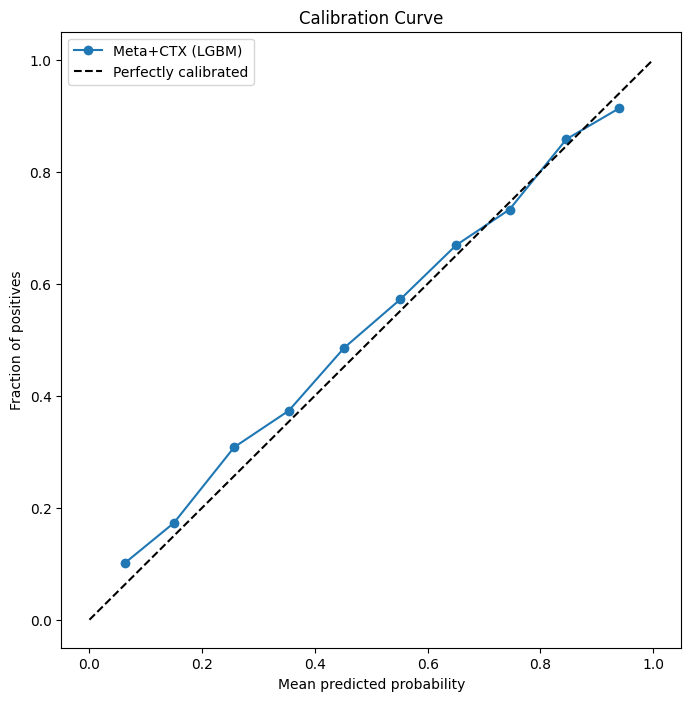

In [ ]:
from sklearn.calibration import calibration_curve
### Check calibration of Metamodel


proba = meta_test
true = y_test
prob_true, prob_pred = calibration_curve(true, proba, n_bins=20)
print("Calibration data (Meta-only):")
for pt, pp in zip(prob_true, prob_pred):
    print(f"Predicted: {pp:.4f}, True: {pt:.4f}")
plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', label='Meta+CTX (LGBM)')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()

In [45]:
import pandas as pd
from sklearn.feature_extraction import DictVectorizer

# ====== zbuduj dataframe z rankingów ======
rank_feat_names = sorted(y_pred.keys())
df_rank = pd.DataFrame(
    {name: y_pred[name] for name in rank_feat_names}
)

# ====== zbuduj dataframe z kontekstu ======
vec = DictVectorizer(sparse=False)
X_ctx_dense = vec.fit_transform(X_ctx)
df_ctx = pd.DataFrame(X_ctx_dense, columns=vec.get_feature_names_out())

# ====== label ======
df_y = pd.DataFrame({"y": y_true})

# ====== połącz wszystko ======
df_all = pd.concat([df_rank, df_ctx, df_y], axis=1)

# ====== zapisz do CSV ======
output_path = "dataset_rankings_ctx.csv"
df_all.to_csv(output_path, index=False)

print(f"Dataset zapisany do: {output_path}")


Dataset zapisany do: dataset_rankings_ctx.csv
